# 02: Training Results & Evaluation Metrics

Visualizes training/evaluation results. Attempts wandb first, then falls back to local JSON artifacts.

**Data sources (in priority order):**
1. `wandb` API — if a run is available and authenticated
2. `../results/eval/per_model_results.json` — per-model evaluation output
3. `../results/eval/metrics.json` — aggregate metrics summary

In [10]:
import json
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")


def find_project_root(start: Path) -> Path:
    candidates = [
        start,
        *start.parents,
        start / "hanomi-repo",
        Path("/kaggle/working/hanomi-repo"),
        Path("/kaggle/input/hanomi-feature-repo"),
    ]
    for candidate in candidates:
        if (candidate / "src").exists() and (candidate / "configs").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
EVAL_DIR = PROJECT_ROOT / "results/runs/run_001/eval"
EVAL_PHASE2_DIR = PROJECT_ROOT / "results/runs/run_002/eval"


## 1. Load Data

In [11]:
per_model_df = None
metrics = None
phase2_metrics = None
wandb_loaded = False

try:
    import wandb
    api = wandb.Api()
    runs = list(api.runs(path=None))
    if runs:
        latest_run = runs[0]
        history = latest_run.history()
        if not history.empty:
            per_model_df = history.copy()
            wandb_loaded = True
            print(f"Loaded {len(per_model_df)} records from wandb run: {latest_run.id}")
except Exception as e:
    print(f"wandb not available ({type(e).__name__}: {e}). Falling back to local files.")

wandb not available (HTTPError: 400 Client Error: Bad Request for url: https://api.wandb.ai/graphql). Falling back to local files.


In [12]:
per_model_path = os.path.join(EVAL_DIR, "per_model_results.json")
if per_model_df is None and os.path.exists(per_model_path):
    with open(per_model_path) as f:
        records = json.load(f)
    per_model_df = pd.DataFrame(records)
    print(f"Loaded {len(per_model_df)} per-model results from {per_model_path}")

metrics_path = os.path.join(EVAL_DIR, "metrics.json")
if os.path.exists(metrics_path):
    with open(metrics_path) as f:
        metrics = json.load(f)
    print(f"Loaded aggregate metrics from {metrics_path}")

phase2_metrics_path = os.path.join(EVAL_PHASE2_DIR, "metrics.json")
if os.path.exists(phase2_metrics_path):
    with open(phase2_metrics_path) as f:
        phase2_metrics = json.load(f)
    print(f"Loaded Phase 2 metrics from {phase2_metrics_path}")

Loaded 4702 per-model results from /Users/anmolsen/Developer/hanomi-feature-recognition/results/runs/run_001/eval/per_model_results.json
Loaded aggregate metrics from /Users/anmolsen/Developer/hanomi-feature-recognition/results/runs/run_001/eval/metrics.json
Loaded Phase 2 metrics from /Users/anmolsen/Developer/hanomi-feature-recognition/results/runs/run_002/eval/metrics.json


In [13]:
if per_model_df is None and metrics is None:
    print("=" * 40)
    print("No evaluation results found.")
    print("=" * 40)
    print()
    print("To generate results, run the evaluation pipeline:")
    print("  python -m src.cli evaluate --config configs/default.yaml")
    print()
    print("Expected output files:")
    print(f"  {per_model_path}")
    print(f"  {metrics_path}")
    print()
    print("Or authenticate wandb to pull run history:")
    print("  wandb login")

## 2. Aggregate Metrics Summary

In [14]:
def print_metrics(label, m):
    if m is None:
        return
    print(f"\n{'=' * 40}")
    print(f"  {label}")
    print(f"{'=' * 40}")
    print(f"  Mean F1:          {m['mean_f1']:.4f}")
    print(f"  Mean Precision:   {m['mean_precision']:.4f}")
    print(f"  Mean Recall:      {m['mean_recall']:.4f}")
    print(f"  Mean Inference:   {m['mean_inference_ms']:.1f} ms")
    print(f"  # Models:         {m['n_models']}")
    if 'per_method' in m:
        print(f"\n  Per-method breakdown:")
        for method, vals in m['per_method'].items():
            print(f"    {method:30s}  F1={vals['mean_f1']:.4f}  P={vals['mean_precision']:.4f}  R={vals['mean_recall']:.4f}  ({vals.get('n_models', '?')} models)")

print_metrics("Phase 1 — Evaluation Results", metrics)
print_metrics("Phase 2 — Evaluation Results", phase2_metrics)


  Phase 1 — Evaluation Results
  Mean F1:          0.8290
  Mean Precision:   0.7709
  Mean Recall:      0.9622
  Mean Inference:   12.0 ms
  # Models:         4702

  Per-method breakdown:
    gnn_seed_expand                 F1=0.8290  P=0.7709  R=0.9622  (4702 models)

  Phase 2 — Evaluation Results
  Mean F1:          0.8104
  Mean Precision:   0.7527
  Mean Recall:      0.9450
  Mean Inference:   13.3 ms
  # Models:         7120

  Per-method breakdown:
    gnn_seed_expand                 F1=0.8104  P=0.7527  R=0.9450  (7120 models)


## 3. F1 / Precision / Recall by Feature Type & Method

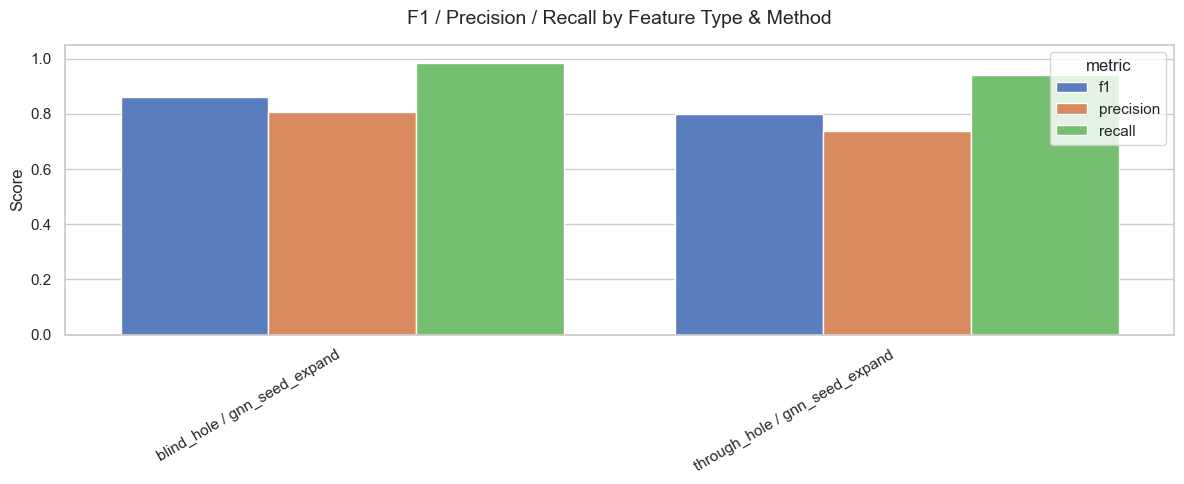

In [15]:
if per_model_df is not None and not per_model_df.empty:
    group_cols = []
    for col in ["feature_type", "method"]:
        if col in per_model_df.columns:
            group_cols.append(col)

    if group_cols:
        agg = (
            per_model_df
            .groupby(group_cols)
            .agg(mean_f1=("f1", "mean"),
                 mean_precision=("precision", "mean"),
                 mean_recall=("recall", "mean"))
            .reset_index()
        )
        agg["label"] = agg[group_cols].astype(str).agg(" / ".join, axis=1)
    else:
        agg = pd.DataFrame({
            "label": ["all"],
            "mean_f1": [per_model_df["f1"].mean()],
            "mean_precision": [per_model_df["precision"].mean()],
            "mean_recall": [per_model_df["recall"].mean()],
        })

    melted = agg.melt(id_vars=["label"],
                       value_vars=["mean_f1", "mean_precision", "mean_recall"],
                       var_name="metric", value_name="score")
    melted["metric"] = melted["metric"].str.replace("mean_", "")

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=melted, x="label", y="score", hue="metric", ax=ax)
    ax.set_title("F1 / Precision / Recall by Feature Type & Method", fontsize=14, pad=15)
    ax.set_ylabel("Score")
    ax.set_xlabel("")
    ax.set_ylim(0, 1.05)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No per-model data available for this chart.")

## 4. Per-Model F1 Distribution

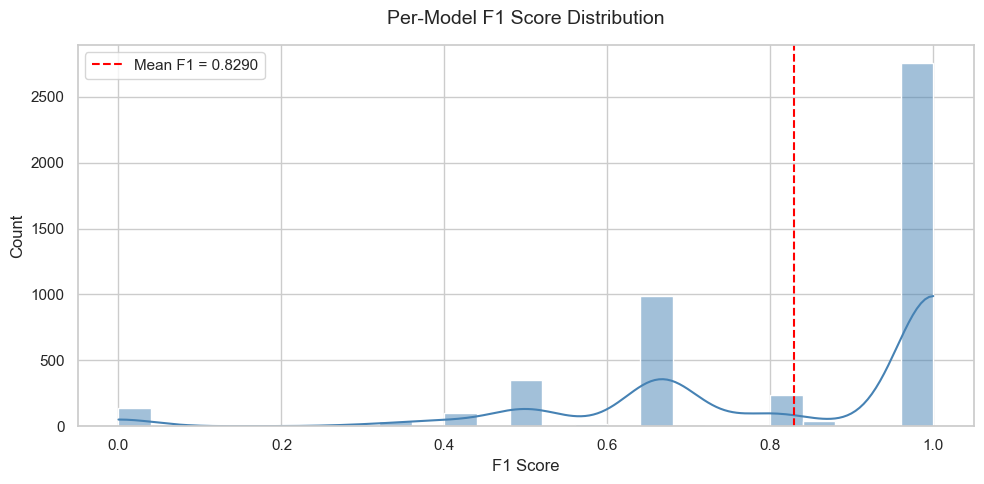

In [16]:
if per_model_df is not None and "f1" in per_model_df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(per_model_df["f1"], bins=25, kde=True, ax=ax, color="steelblue", edgecolor="white")
    mean_f1 = per_model_df["f1"].mean()
    ax.axvline(mean_f1, color="red", linestyle="--", linewidth=1.5, label=f"Mean F1 = {mean_f1:.4f}")
    ax.set_title("Per-Model F1 Score Distribution", fontsize=14, pad=15)
    ax.set_xlabel("F1 Score")
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No per-model F1 data available for this chart.")

## 5. Inference Time Distribution

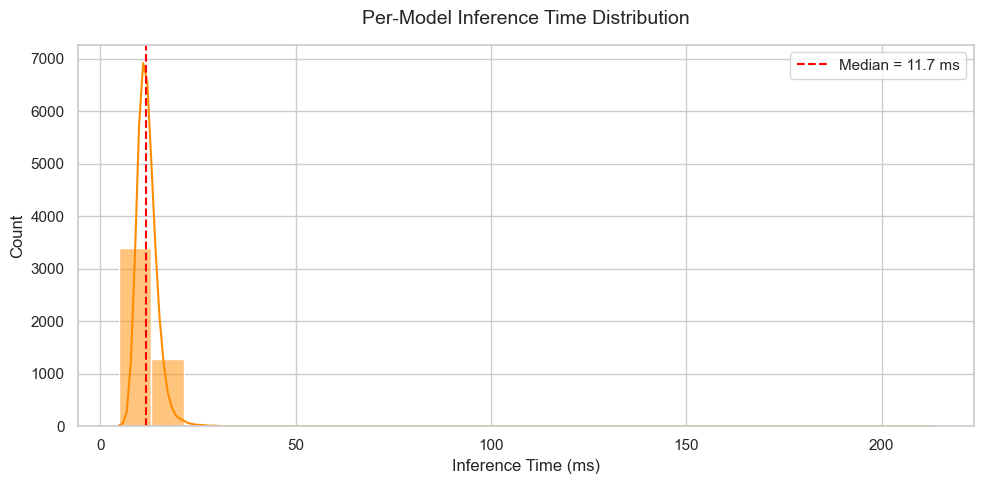

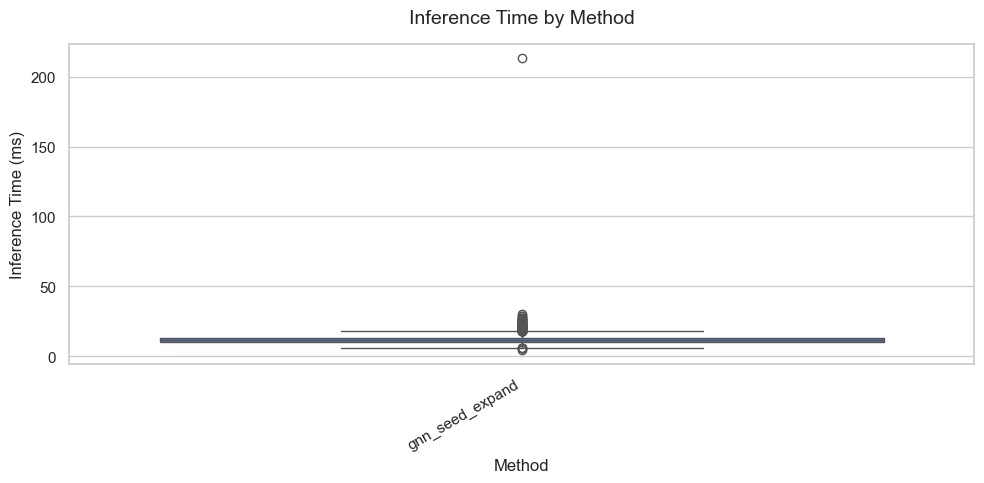

In [17]:
if per_model_df is not None and "inference_ms" in per_model_df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    times = per_model_df["inference_ms"]
    sns.histplot(times, bins=25, kde=True, ax=ax, color="darkorange", edgecolor="white")
    med = times.median()
    ax.axvline(med, color="red", linestyle="--", linewidth=1.5, label=f"Median = {med:.1f} ms")
    ax.set_title("Per-Model Inference Time Distribution", fontsize=14, pad=15)
    ax.set_xlabel("Inference Time (ms)")
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()

    if "method" in per_model_df.columns:
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.boxplot(data=per_model_df, x="method", y="inference_ms", ax=ax)
        ax.set_title("Inference Time by Method", fontsize=14, pad=15)
        ax.set_xlabel("Method")
        ax.set_ylabel("Inference Time (ms)")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()
else:
    print("No per-model inference timing data available for this chart.")

## 6. Phase 1 vs Phase 2 Comparison

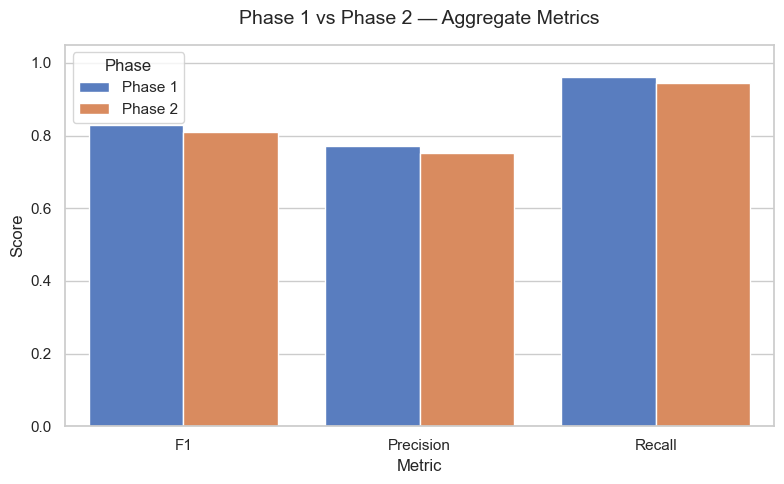

In [18]:
if metrics is not None and phase2_metrics is not None:
    comparison = pd.DataFrame({
        "Phase": ["Phase 1", "Phase 2"],
        "F1": [metrics["mean_f1"], phase2_metrics["mean_f1"]],
        "Precision": [metrics["mean_precision"], phase2_metrics["mean_precision"]],
        "Recall": [metrics["mean_recall"], phase2_metrics["mean_recall"]],
    })
    melted = comparison.melt(id_vars=["Phase"], var_name="Metric", value_name="Score")

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=melted, x="Metric", y="Score", hue="Phase", ax=ax)
    ax.set_title("Phase 1 vs Phase 2 — Aggregate Metrics", fontsize=14, pad=15)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
else:
    missing = []
    if metrics is None:
        missing.append("Phase 1")
    if phase2_metrics is None:
        missing.append("Phase 2")
    print(f"No Phase comparison available (missing: {', '.join(missing)}).")
    print(f"Phase 2 metrics file expected at: {os.path.join(EVAL_PHASE2_DIR, 'metrics.json')}")